# TVB-schz — Visualization
Classification results, J_i group differences and shuffle diagnostics.
Companion to `inspect_results.ipynb` (single-subject / single-fit inspection);
this notebook aggregates across subjects and experiments.

Run cells top to bottom, edit the config block below to point at your results.

In [2]:
# Run from the repo root (same convention as inspect_results.ipynb) so
# `utils` and `configs/classification.yaml` resolve as relative paths.
from pathlib import Path

import numpy as np
import pandas as pd

from utils.results_io import (
    load_J_i_by_group,
    load_all_classification_results,
    load_graph_shuffle_fit_quality,
    load_graph_shuffle_matrices,
)
from utils.plotting import (
    plot_feature_vs_feature,
    plot_graph_shuffle_examples,
    plot_graph_shuffle_fit_quality,
    plot_J_i_difference,
    plot_shuffle_comparison,
    save_table,
    summary_table,
)
from utils.tools import expand_path, parse_config

# ── EDIT THESE ────────────────────────────────────────────
cfg = parse_config("configs/classification.yaml")

RESULTS_DIR      = expand_path(cfg["output_dir"])          # EI-tuning results
CLASSIFICATION_DIR = expand_path(cfg["save_dir"])           # run_classification.py output
SHUFFLE_DIR       = expand_path(cfg["data_dir"]) / "shuffle"

WEIGHT_TYPES = list(cfg["weight_types"])                    # ADC, gFA, density, number
PARC         = cfg["parcellation"]                          # 83
CLASSIFIERS  = ["SGD", "RF"]
EXPS         = ["normal", "shuffle_region", "shuffle_subj"]
# ──────────────────────────────────────────────────────────

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## 1. Classification — SGD & RF
Load every `{classifier}_{exp}.npy` written by `run_classification.py` into one DataFrame.

In [3]:
scores = load_all_classification_results(CLASSIFICATION_DIR, CLASSIFIERS, EXPS)
print(f"{len(scores)} rows | classifiers={scores['classifier'].unique().tolist()} "
      f"| exps={scores['exp'].unique().tolist()} | features={scores['feature'].unique().tolist()}")
scores.head()

0 rows | classifiers=[] | exps=[] | features=[]


,classifier,exp,feature,weight_metric,split,score


## 2. Classification plots
Split-violin comparison between feature sets, one panel per weight metric,
with chance level (0.5), benchmark (0.98) and FDR-corrected Wilcoxon
significance stars — see `utils.plotting.plot_score_violin`.

ZeroDivisionError: float division by zero

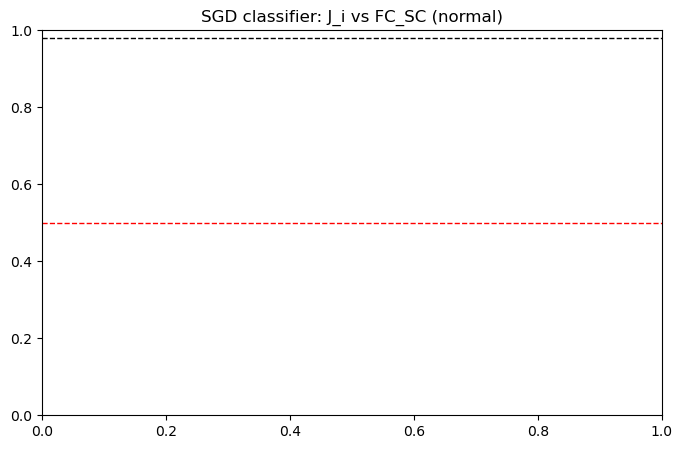

In [25]:
FEATURE_A, FEATURE_B = "J_i", "FC_SC"

for classifier in CLASSIFIERS:
    ax = plot_feature_vs_feature(scores, FEATURE_A, FEATURE_B, classifier=classifier, exp="normal")
    ax.figure.savefig(FIG_DIR / f"{classifier}_{FEATURE_A}_vs_{FEATURE_B}.pdf", bbox_inches="tight")

In [ ]:
# Any other feature pair, e.g. structural connectivity descriptors
for classifier in CLASSIFIERS:
    ax = plot_feature_vs_feature(scores, "SC_eig", "SC_deg", classifier=classifier, exp="normal")
    ax.figure.savefig(FIG_DIR / f"{classifier}_SC_eig_vs_SC_deg.pdf", bbox_inches="tight")

## 3. J_i differences — ctrl vs schz
Per-region mean(J_i schz) - mean(J_i ctrl), SEM error bars, FDR-corrected
Mann-Whitney U significance stars. 

In [ ]:
EXP_FOR_J_I = "normal"

for weight_type in WEIGHT_TYPES:
    J_i_by_group = load_J_i_by_group(RESULTS_DIR, EXP_FOR_J_I, weight_type, PARC)
    if len(J_i_by_group["ctrl"]) == 0 or len(J_i_by_group["schz"]) == 0:
        print(f"{weight_type}: no data, skipping")
        continue

    ax, p_corrected = plot_J_i_difference(
        J_i_by_group["ctrl"], J_i_by_group["schz"],
        title=f"J_i difference (schz - ctrl) — {weight_type}, {EXP_FOR_J_I}",
    )
    ax.figure.savefig(FIG_DIR / f"J_i_diff_{weight_type}_{EXP_FOR_J_I}.pdf", bbox_inches="tight")
    print(f"{weight_type}: {(p_corrected < 0.05).sum()} / {len(p_corrected)} regions significant (p<0.05, FDR)")

## 4. Regional & subject shuffle plots
Test-score violin for `normal` vs `shuffle_region` vs `shuffle_subj`, per
weight metric — a real classifier gap here vs. a gap that survives
shuffling would indicate the effect is not driven by regional/subject
identity alone.

In [ ]:
SHUFFLE_FEATURE = "J_i"

for classifier in CLASSIFIERS:
    for weight_type in WEIGHT_TYPES:
        ax = plot_shuffle_comparison(scores, feature=SHUFFLE_FEATURE, weight_metric=weight_type, classifier=classifier)
        ax.figure.savefig(FIG_DIR / f"{classifier}_{SHUFFLE_FEATURE}_{weight_type}_shuffle_comparison.pdf", bbox_inches="tight")

## 5. Graph shuffle plot
Erdos-Renyi surrogate graphs (see `utils/generate_shuffles.py`) at fixed
mean edge weight, varying sparsity — example graphs plus EI-tuning fit
quality (final FC correlation) as sparsity increases.

In [ ]:
EXAMPLE_WEIGHT_TYPE = WEIGHT_TYPES[0]
EXAMPLE_SPARSITY = 0.4

graphs = load_graph_shuffle_matrices(SHUFFLE_DIR, EXAMPLE_WEIGHT_TYPE, EXAMPLE_SPARSITY)
fig = plot_graph_shuffle_examples(graphs, EXAMPLE_WEIGHT_TYPE, EXAMPLE_SPARSITY)
fig.savefig(FIG_DIR / f"graph_shuffle_examples_{EXAMPLE_WEIGHT_TYPE}_spar{EXAMPLE_SPARSITY}.pdf", bbox_inches="tight")

In [ ]:
SPARSITIES = [0.2, 0.4, 0.6, 0.8, 1.0]

for weight_type in WEIGHT_TYPES:
    fit_quality = load_graph_shuffle_fit_quality(RESULTS_DIR, weight_type, PARC, SPARSITIES)
    if fit_quality.empty:
        print(f"{weight_type}: no shuffle_graph results")
        continue
    ax = plot_graph_shuffle_fit_quality(fit_quality, weight_type=weight_type)
    ax.figure.savefig(FIG_DIR / f"graph_shuffle_fit_quality_{weight_type}.pdf", bbox_inches="tight")

## 6. Summary table
Mean ± std test score per (classifier, exp, feature, weight metric),
highlighted by best score per (classifier, exp, feature).

In [ ]:
table = summary_table(scores)
save_table(table, FIG_DIR / "classification_summary.csv")

best_idx = table.groupby(["classifier", "exp", "feature"])["mean"].idxmax()
table.loc[best_idx].style.set_caption("Best weight metric per (classifier, exp, feature)")

In [ ]:
table.pivot_table(index=["classifier", "feature"], columns="exp", values="mean ± std", aggfunc="first")